In [22]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision import models, transforms

# ==========================================
# 1. ROBUST SEMANTIC SALIENCY GENERATOR
# ==========================================


def generate_clean_saliency(image_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Use a pre-trained MobileNetV3-Large. It has highly optimized semantic feature extraction
    # and handles object boundaries much more cleanly without random decoder noise.
    model = models.mobilenet_v3_large(weights="DEFAULT")
    features = model.features
    features.eval().to(device)

    # Load image
    raw_img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = raw_img.size

    # Transform for the neural network
    transform = transforms.Compose(
        [
            transforms.Resize((448, 448)),  # Higher resolution for sharper features
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
            ),
        ]
    )
    input_tensor = transform(raw_img).unsqueeze(0).to(device)

    # Extract deep feature maps
    with torch.no_grad():
        feat_maps = features(input_tensor)  # Shape: [1, 960, 14, 14]

    # Compute the mean activation across all channels to find the core semantic focus
    heatmap_raw = torch.mean(feat_maps, dim=1).squeeze().cpu().numpy()

    # Resize map back to original image dimensions
    heatmap_resized = cv2.resize(heatmap_raw, (orig_w, orig_h))

    # ==========================================
    # 2. COMBINE WITH FINE-GRAINED LOW-LEVEL SALIENCY
    # ==========================================
    # This prevents the map from missing sharp boundaries (like the trunk or ears)
    img_cv = cv2.cvtColor(np.array(raw_img), cv2.COLOR_RGB2BGR)
    saliency_object = cv2.saliency.StaticSaliencyFineGrained_create()
    success, fine_saliency = saliency_object.computeSaliency(img_cv)
    fine_saliency = (fine_saliency * 255).astype(np.uint8)

    # Normalize deep heatmap
    heatmap_norm = (heatmap_resized - heatmap_resized.min()) / (
        heatmap_resized.max() - heatmap_resized.min() + 1e-8
    )
    heatmap_norm = (heatmap_norm * 255).astype(np.uint8)

    # Blend high-level semantic focus (70%) with low-level fine details (30%)
    fused_saliency = cv2.addWeighted(heatmap_norm, 0.7, fine_saliency, 0.3, 0)

    # Smooth the transitions using a large Gaussian Kernel to match human eye fixations
    # Adjust the sigma (last parameter) to make the focus wider or narrower
    blurred_saliency = cv2.GaussianBlur(fused_saliency, (55, 55), 0)

    # Final normalization
    blurred_saliency = (
        (blurred_saliency - blurred_saliency.min())
        / (blurred_saliency.max() - blurred_saliency.min() + 1e-8)
        * 255
    ).astype(np.uint8)

    # Color map generation
    heatmap_color = cv2.applyColorMap(blurred_saliency, cv2.COLORMAP_JET)

    # Overlay with original image
    output_img = cv2.addWeighted(img_cv, 0.6, heatmap_color, 0.4, 0)
    output_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

    # ==========================================
    # 3. DISPLAY RESULTS
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(raw_img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(output_img)
    axes[1].set_title("Fixed Clean Saliency Map")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


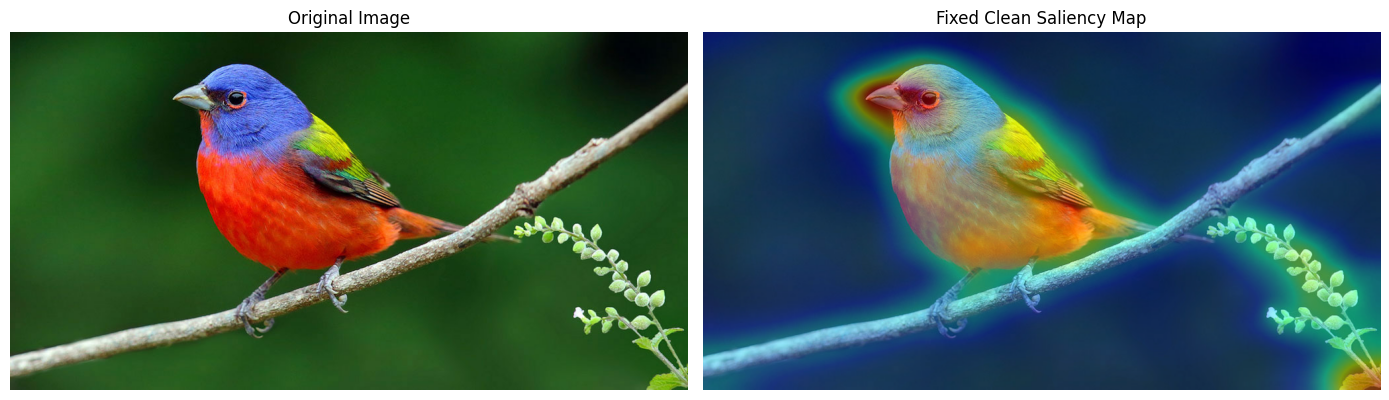

In [27]:
generate_clean_saliency('../images/bird.jpg')